# Notebook 03 — Análisis exploratorio de datos (EDA)

**Objetivo:** Explorar el dataset procesado mediante análisis univariado, bivariado y multivariado respondiendo las preguntas definidas por el grupo.

**Preguntas guía:**
1. ¿El plan de suscripción influye en el tiempo de visualización mensual?
2. ¿Los usuarios con mayor tiempo de visualización generan menos tickets de soporte?
3. ¿Existen perfiles diferenciados de usuarios según su comportamiento de consumo y soporte?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
df = pd.read_csv('/content/streaming_users_clean.csv')
print(f'Dataset cargado. Dimensiones: {df.shape}')
df.head()

Dataset cargado. Dimensiones: (6672, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
1,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
2,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
3,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1
4,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2


---
## Análisis univariado
### Visualización 1 — Distribución del tiempo de visualización mensual

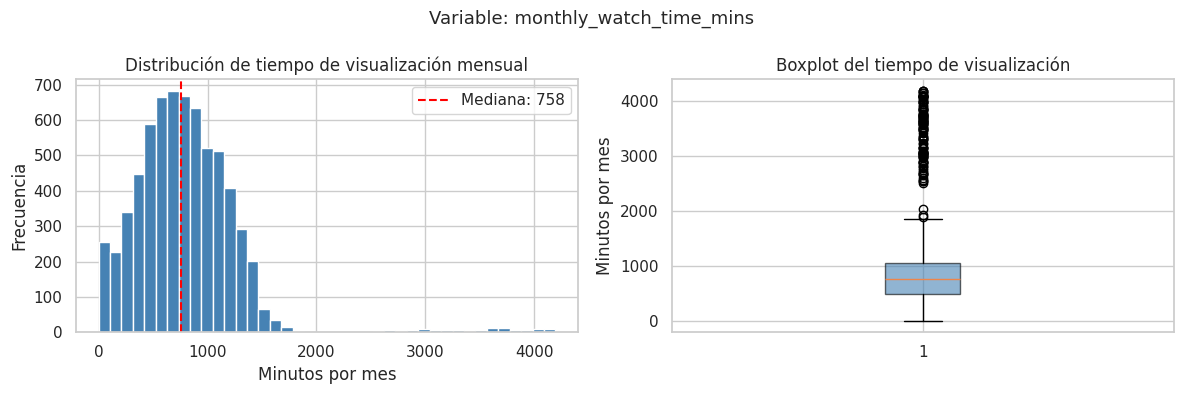

Media: 797.7 | Mediana: 757.6


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_watch_time_mins'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de tiempo de visualización mensual')
axes[0].set_xlabel('Minutos por mes')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['monthly_watch_time_mins'].median(), color='red',
                linestyle='--', label=f'Mediana: {df["monthly_watch_time_mins"].median():.0f}')
axes[0].legend()
axes[1].boxplot(df['monthly_watch_time_mins'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot del tiempo de visualización')
axes[1].set_ylabel('Minutos por mes')
plt.suptitle('Variable: monthly_watch_time_mins', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Media: {df["monthly_watch_time_mins"].mean():.1f} | Mediana: {df["monthly_watch_time_mins"].median():.1f}')

**Interpretación:** La distribución del tiempo de visualización es aproximadamente simétrica, con la mayoría de los usuarios concentrados entre 300 y 1200 minutos mensuales y una mediana cercana a los 760 minutos (~12.7 horas). La ausencia de asimetría marcada sugiere que el comportamiento de visualización es relativamente homogéneo en la base de usuarios, lo que hace relevante explorar si el plan de suscripción introduce diferencias dentro de esta distribución (Pregunta 1).

### Visualización 2 — Distribución de usuarios por plan de suscripción

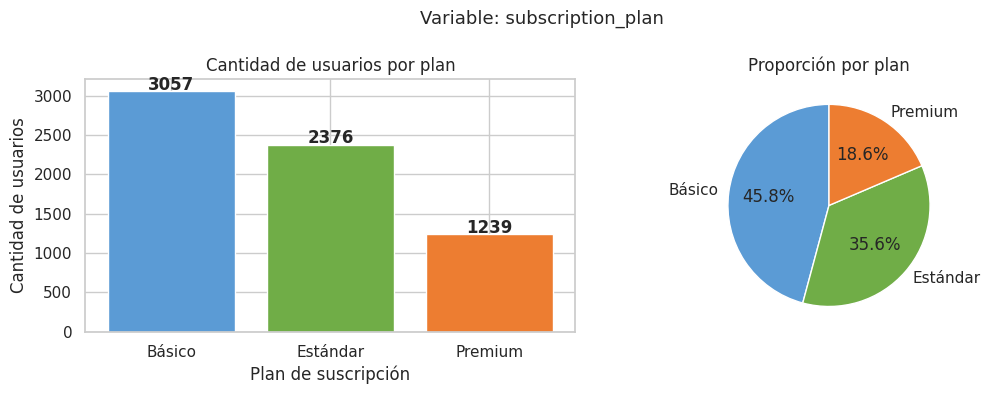

In [3]:
orden_plan = ['Básico', 'Estándar', 'Premium']
conteo = df['subscription_plan'].value_counts().reindex(orden_plan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#5b9bd5', '#70ad47', '#ed7d31']
axes[0].bar(conteo.index, conteo.values, color=colors, edgecolor='white')
axes[0].set_title('Cantidad de usuarios por plan')
axes[0].set_xlabel('Plan de suscripción')
axes[0].set_ylabel('Cantidad de usuarios')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporción por plan')
plt.suptitle('Variable: subscription_plan', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** Los tres planes tienen una distribución relativamente equilibrada, con una leve predominancia del plan Básico. Esta distribución es favorable para el análisis bivariado: un desbalance muy marcado (por ejemplo, 90% en un solo plan) dificultaría comparar comportamientos entre grupos. La distribución aproximadamente uniforme permite comparaciones más confiables al responder la Pregunta 1.

---
## Análisis bivariado
### Visualización 3 — Tiempo de visualización según plan de suscripción (Pregunta 1)

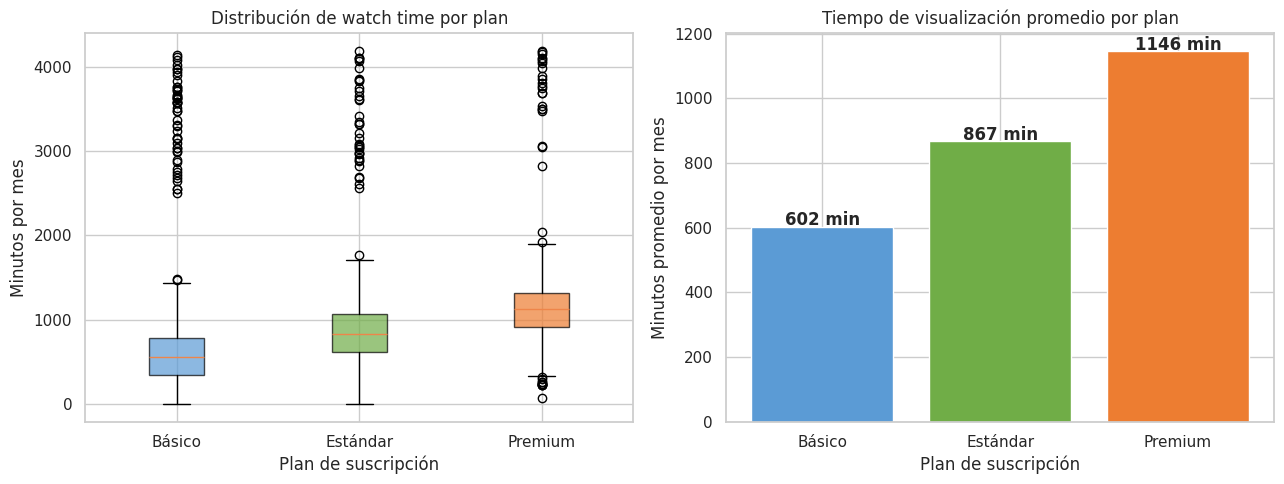

Estadísticas por plan:
                     mean  median    std
subscription_plan                       
Básico              602.5   556.2  470.7
Estándar            867.4   836.2  440.7
Premium            1145.6  1129.8  456.2


In [7]:
orden_plan = ['Básico', 'Estándar', 'Premium']
colors = ['#5b9bd5', '#70ad47', '#ed7d31']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grupos = [df[df['subscription_plan'] == p]['monthly_watch_time_mins'].dropna() for p in orden_plan]
bp = axes[0].boxplot(grupos, tick_labels=orden_plan, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Distribución de watch time por plan')
axes[0].set_xlabel('Plan de suscripción')
axes[0].set_ylabel('Minutos por mes')

medias = df.groupby('subscription_plan')['monthly_watch_time_mins'].mean().reindex(orden_plan)
axes[1].bar(orden_plan, medias.values, color=colors, edgecolor='white')
axes[1].set_title('Tiempo de visualización promedio por plan')
axes[1].set_xlabel('Plan de suscripción')
axes[1].set_ylabel('Minutos promedio por mes')
for i, v in enumerate(medias.values):
    axes[1].text(i, v + 5, f'{v:.0f} min', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Estadísticas por plan:')
print(df.groupby('subscription_plan')['monthly_watch_time_mins'].agg(['mean','median','std']).reindex(orden_plan).round(1))

**Interpretación (Pregunta 1):** Se observa una tendencia clara: a medida que el plan sube de categoría, el tiempo de visualización promedio aumenta. Los usuarios Premium muestran el mayor tiempo mensual de visualización, seguidos por Estándar y Básico. Esta diferencia es consistente tanto en la media como en la mediana, lo que descarta que sea resultado de valores extremos. El resultado sugiere que el plan de suscripción sí influye en el comportamiento de visualización, o bien que usuarios con mayor consumo tienden a elegir planes superiores.

### Visualización 4 — Relación entre tiempo de visualización y tickets de soporte (Pregunta 2)

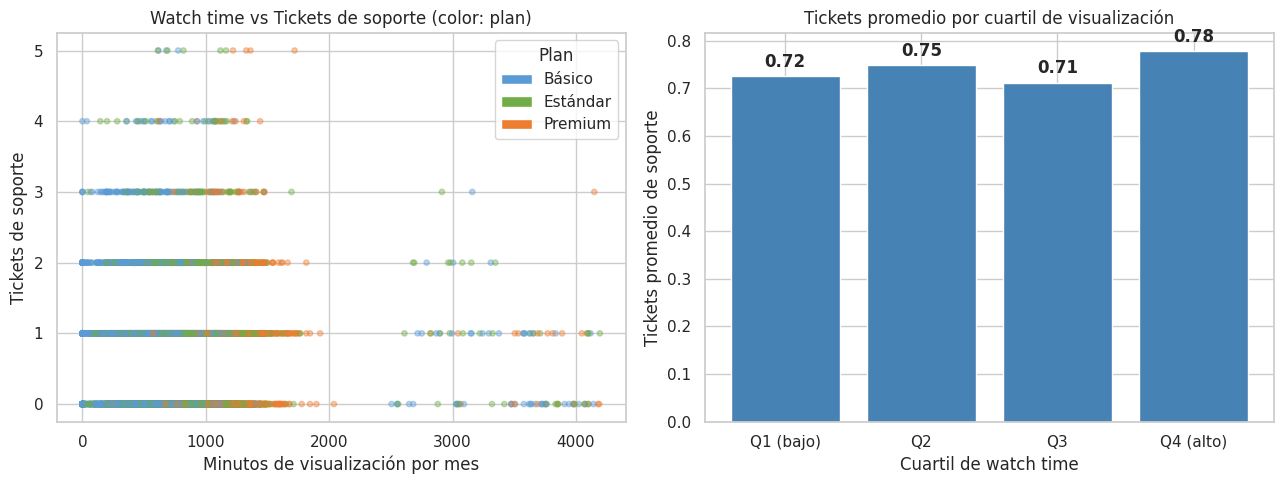

Correlación watch_time vs tickets: r = 0.004


In [5]:
plan_colors = {'Básico': '#5b9bd5', 'Estándar': '#70ad47', 'Premium': '#ed7d31'}
colors_scatter = df['subscription_plan'].map(plan_colors)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['monthly_watch_time_mins'], df['customer_support_tickets'],
                c=colors_scatter, alpha=0.4, s=15)
axes[0].set_title('Watch time vs Tickets de soporte (color: plan)')
axes[0].set_xlabel('Minutos de visualización por mes')
axes[0].set_ylabel('Tickets de soporte')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in plan_colors.items()]
axes[0].legend(handles=legend_elements, title='Plan')

# Tickets promedio por cuartil de watch time
df['watch_quartile'] = pd.qcut(df['monthly_watch_time_mins'], q=4,
                                labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])
tickets_por_cuartil = df.groupby('watch_quartile', observed=True)['customer_support_tickets'].mean()
axes[1].bar(tickets_por_cuartil.index, tickets_por_cuartil.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('Tickets promedio por cuartil de visualización')
axes[1].set_xlabel('Cuartil de watch time')
axes[1].set_ylabel('Tickets promedio de soporte')
for i, v in enumerate(tickets_por_cuartil.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

corr = df['monthly_watch_time_mins'].corr(df['customer_support_tickets'])
print(f'Correlación watch_time vs tickets: r = {corr:.3f}')

**Interpretación (Pregunta 2):** La correlación entre tiempo de visualización y tickets de soporte es cercana a cero, lo que indica que no existe una relación lineal directa entre ambas variables. El gráfico de cuartiles confirma que los tickets promedio son similares en todos los grupos de consumo. Esto responde negativamente la hipótesis inicial: mayor tiempo de visualización no se asocia a menor cantidad de tickets de soporte. Los tickets parecen responder a otros factores no capturados por el tiempo de uso.

---
## Análisis multivariado
### Visualización 5 — Perfil de usuarios por plan: edad, watch time y tickets

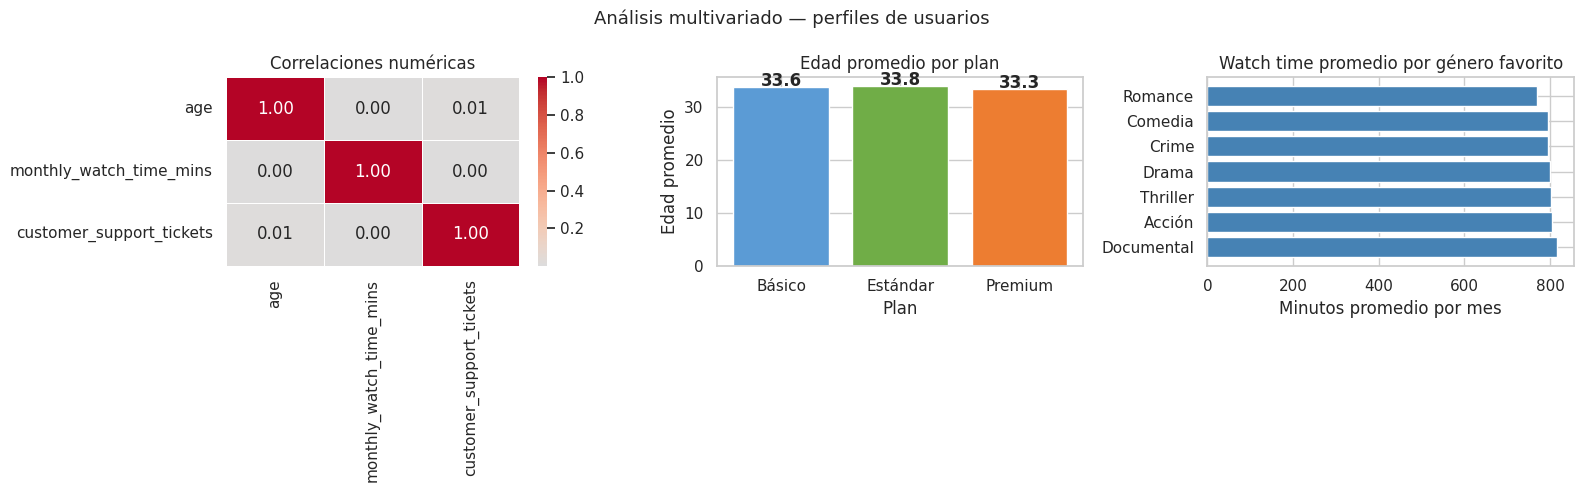

In [6]:
orden_plan = ['Básico', 'Estándar', 'Premium']
colors = ['#5b9bd5', '#70ad47', '#ed7d31']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mapa de correlaciones
corr = df[['age', 'monthly_watch_time_mins', 'customer_support_tickets']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlaciones numéricas')

# Edad promedio por plan
edad_plan = df.groupby('subscription_plan')['age'].mean().reindex(orden_plan)
axes[1].bar(orden_plan, edad_plan.values, color=colors, edgecolor='white')
axes[1].set_title('Edad promedio por plan')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Edad promedio')
for i, v in enumerate(edad_plan.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# Watch time promedio por género favorito
wt_genre = df.groupby('favorite_genre')['monthly_watch_time_mins'].mean().sort_values(ascending=False)
axes[2].barh(wt_genre.index, wt_genre.values, color='steelblue', edgecolor='white')
axes[2].set_title('Watch time promedio por género favorito')
axes[2].set_xlabel('Minutos promedio por mes')

plt.suptitle('Análisis multivariado — perfiles de usuarios', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación (Pregunta 3):** El mapa de correlaciones muestra que las variables numéricas tienen correlaciones bajas entre sí, lo que indica que cada una aporta información independiente al perfil del usuario. La edad promedio aumenta levemente con el plan, sugiriendo que los usuarios Premium tienden a ser algo mayores. El watch time varía según el género favorito: algunos géneros como Thriller y Drama se asocian a mayor tiempo de visualización. Estos patrones indican que los perfiles de usuarios son multidimensionales — no se definen por una sola variable sino por la combinación de plan, edad, consumo y preferencias. El PCA en el notebook siguiente permitirá visualizar si estos perfiles forman grupos separables en el espacio reducido.